<a href="https://colab.research.google.com/github/Mohsin-22/Assignment2-100_Gen-Ai_cohort/blob/main/chapter_appendix-tools-for-deep-learning/jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment 2 :** Assignment: Building an Image Classifier with CNN using MNIST Dataset

**Objective:**
The goal of this assignment is to guide learners through building a Convolutional Neural
Network (CNN) for classifying handwritten digits using the MNIST dataset. After training the
model, learners will test it with their own custom images and verify if it classifies the
images correctly.


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

# Loading the dataset
print("Loading MNIST data...")
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

print(f"Train images shape: {train_images.shape}")
print(f"Test images shape: {test_images.shape}")

Loading MNIST data...
Train images shape: (60000, 28, 28)
Test images shape: (10000, 28, 28)


In [2]:
# Preprocessing :-
# 1. Reshaping the images to (28, 28, 1)
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

# 2. Here im Normalizing the pixel values to be between 0 and 1
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

# 3. One-hot encode the labels
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

print("Preprocessing complete.")

Preprocessing complete.


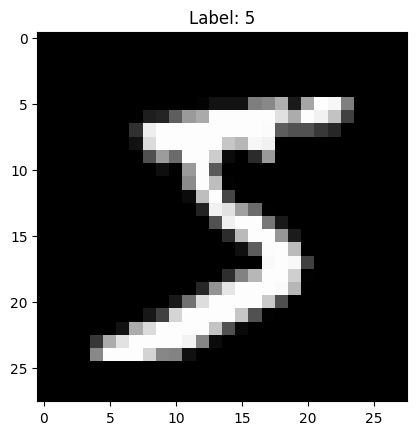

In [3]:
# checking the first image in the training set
plt.imshow(train_images[0].reshape(28, 28), cmap='gray')
plt.title(f"Label: {np.argmax(train_labels[0])}")
plt.show()

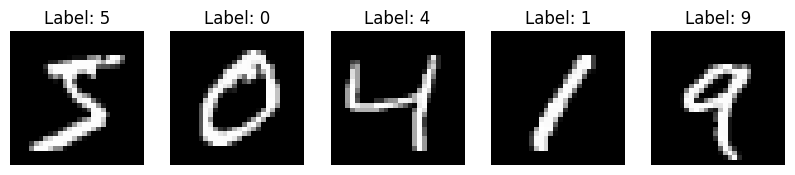

In [4]:
# just a Sanity Check viewing the first 5 images and their labels
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(train_images[i].reshape(28, 28), cmap='gray')
    label = np.argmax(train_labels[i])
    plt.title(f"Label: {label}")
    plt.axis('off')
plt.show()

In [5]:
model = models.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Classifier Head
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Helps reach that 98% accuracy by preventing overfitting
    layers.Dense(10, activation='softmax') # 10 neurons for digits 0-9
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Compiling the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Training the Model
print("Starting training...")
history = model.fit(train_images, train_labels,
                    epochs=10,
                    batch_size=64,
                    validation_split=0.1)

Starting training...
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 49s 56ms/step - accuracy: 0.8904 - loss: 0.3467 - val_accuracy: 0.9825 - val_loss: 0.0571
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 56ms/step - accuracy: 0.9694 - loss: 0.1088 - val_accuracy: 0.9893 - val_loss: 0.0363
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 55ms/step - accuracy: 0.9775 - loss: 0.0776 - val_accuracy: 0.9893 - val_loss: 0.0391
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.9829 - loss: 0.0633 - val_accuracy: 0.9913 - val_loss: 0.0328
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - accuracy: 0.9859 - loss: 0.0481 - val_accuracy: 0.9908 - val_loss: 0.0351
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 55ms/step - accuracy: 0.9882 - loss: 0.0407 - val_accuracy: 0.9917 - val_loss: 0.0285
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 54ms/step - accuracy: 0.9898 - loss: 0.0365 - val_accuracy: 0.9932 - val_loss: 0.0289
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 55ms/step - accuracy: 0.9

In [8]:
# Evaluating on the test set
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

print(f'\nTest accuracy: {test_acc*100:.2f}%')

313/313 - 3s - 9ms/step - accuracy: 0.9915 - loss: 0.0323

Test accuracy: 99.15%


Saving 9image.png to 9image (5).png
Saving 8image.png to 8image (5).png
Saving 7image.png to 7image (5).png
Saving 6image.png to 6image (5).png
Saving 5image.png to 5image (5).png
Saving 4image.png to 4image (5).png
Saving 2image.png to 2image (5).png
Saving 1image.png to 1image (5).png
Saving 3image - Copy.png to 3image - Copy (1).png
Saving 3image.png to 3image (5).png
Saving Media (1).jpg to Media (1) (4).jpg
Saving Media.jpg to Media (5).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


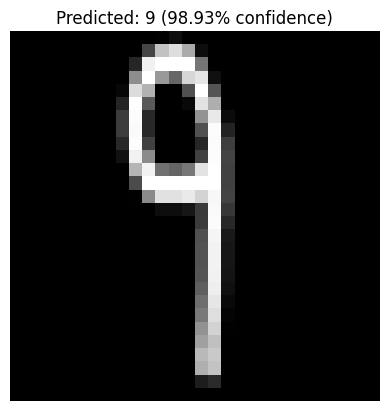

File 9image (5).png is predicted as a 9.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


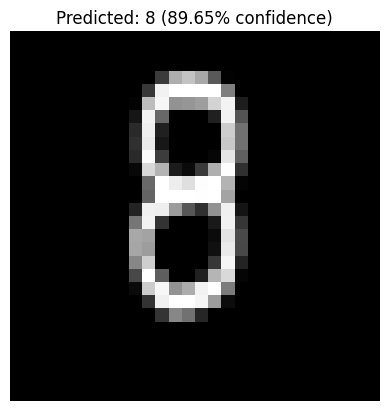

File 8image (5).png is predicted as a 8.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


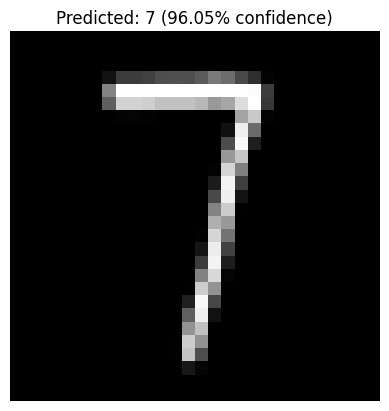

File 7image (5).png is predicted as a 7.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


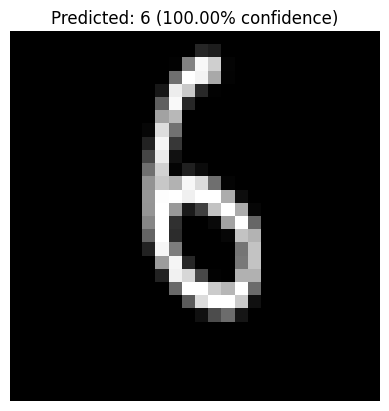

File 6image (5).png is predicted as a 6.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


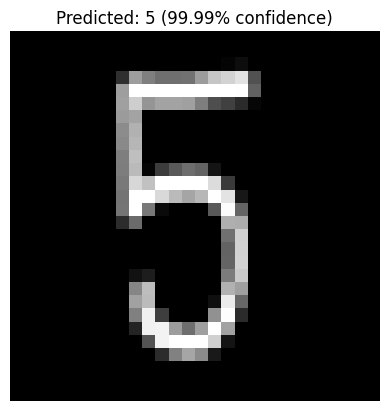

File 5image (5).png is predicted as a 5.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


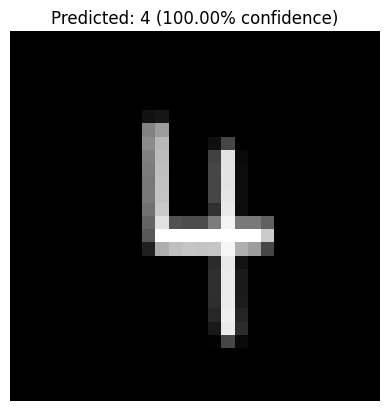

File 4image (5).png is predicted as a 4.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


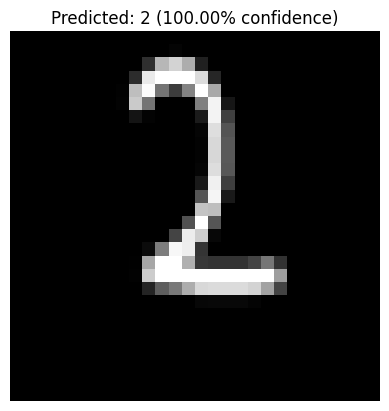

File 2image (5).png is predicted as a 2.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


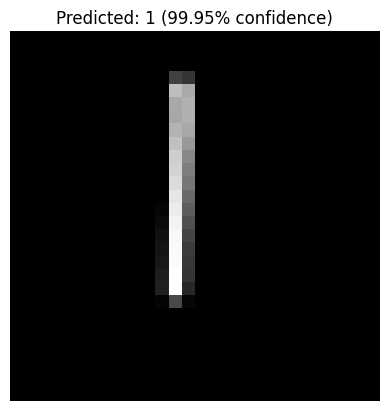

File 1image (5).png is predicted as a 1.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


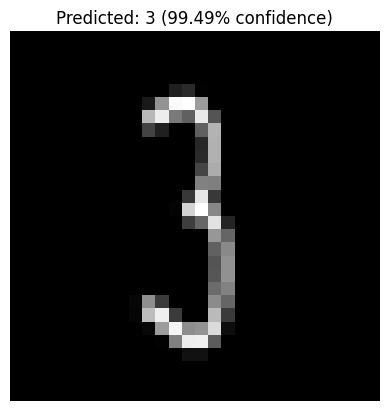

File 3image - Copy (1).png is predicted as a 3.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


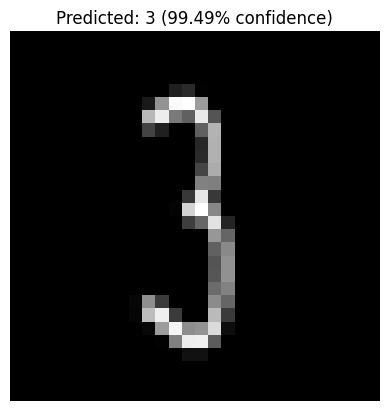

File 3image (5).png is predicted as a 3.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


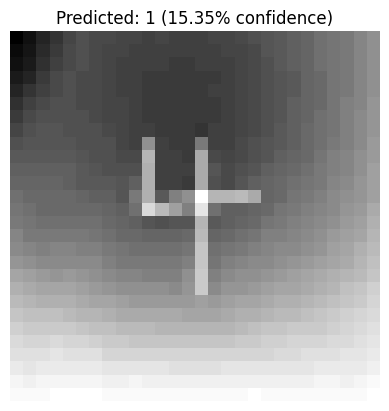

File Media (1) (4).jpg is predicted as a 1.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


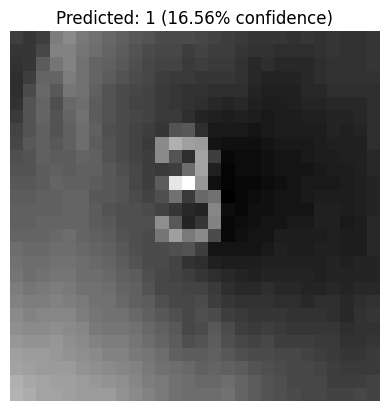

File Media (5).jpg is predicted as a 1.


In [21]:
from google.colab import files
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

for fn in uploaded.keys():
    # Loading the image and convert to Grayscale L
    img = Image.open(fn).convert('L')

    # Resizing to 28x28 and also inverting because the image which iam uploading is black ink on white background from paint tool and the dataset images are white ink on black ground.
    img = img.resize((28, 28))
    img = ImageOps.invert(img)

    # Converting the numpy array and normalize to [0, 1]
    img_array = np.array(img).astype('float32') / 255

    # Reshaping to match the model's input shape (1, 28, 28, 1)
    img_array = img_array.reshape(1, 28, 28, 1)

    # Makning the prediction
    prediction = model.predict(img_array)
    predicted_digit = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    # Visualizing result
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted: {predicted_digit} ({confidence:.2f}% confidence)")
    plt.axis('off')
    plt.show()

    print(f"File {fn} is predicted as a {predicted_digit}.")